In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

In [2]:
lamb = 0.75  # Lambda of the model
mu = -0.6  # Mu
delta = 0.25  # Delta

In [3]:
r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
T = 1.0  # Maturity/time period (in years)
S0 = 100  # Current Stock Price

I = 10000  # Number of simulations (paths)
M = 50  # Number of steps
dt = T / M  # Time-step

In [4]:
SM = np.zeros((M + 1, I))
SM[0] = S0

# rj
rj = lamb * (np.exp(mu + 0.5 * delta**2) - 1)

# Random numbers
z1 = np.random.standard_normal((M + 1, I))
z2 = np.random.standard_normal((M + 1, I))
y = np.random.poisson(lamb * dt, (M + 1, I))

In [5]:
for t in range(1, M + 1):
    SM[t] = SM[t - 1] * (
        np.exp((r - rj - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z1[t])
        + (np.exp(mu + delta * z2[t]) - 1) * y[t]
    )
    SM[t] = np.maximum(
        SM[t], 0.00001
    )  # To ensure that the price never goes below zero!

Let's see how stock price evaluation looks for a sample of 50 paths:

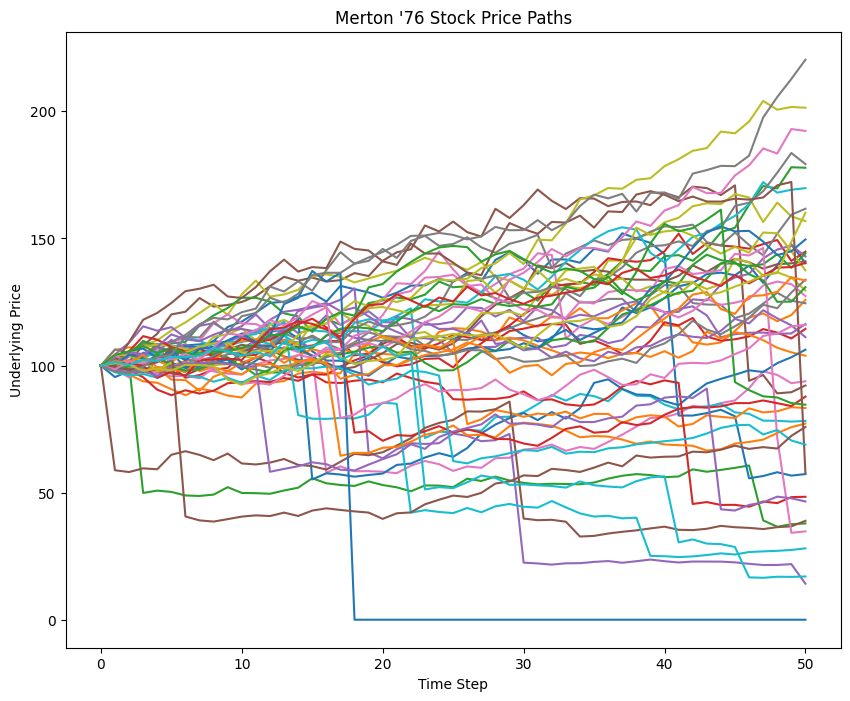

In [6]:
plt.figure(figsize=(10, 8))
plt.plot(SM[:, 100:150])
plt.title("Merton '76 Stock Price Paths")
plt.xlabel("Time Step")
plt.ylabel("Underlying Price")
plt.show()

What is the distribution of stock returns that this model produces?

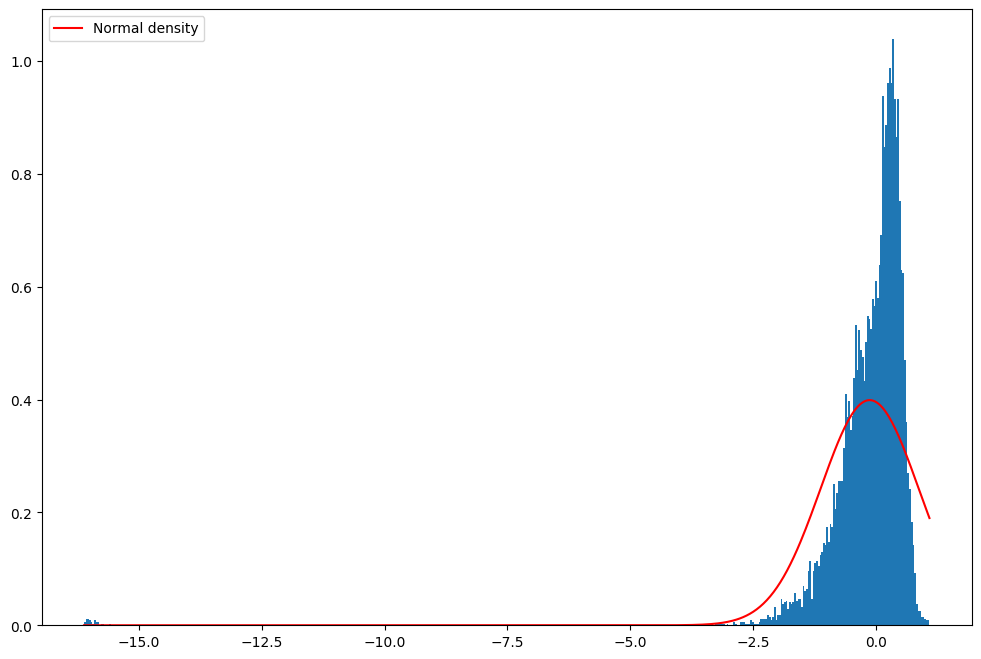

In [7]:
retSM = np.log(SM[-1, :] / S0)
x = np.linspace(retSM.min(), retSM.max(), 500)

plt.figure(figsize=(12, 8))
plt.hist(retSM, density=True, bins=500)
plt.plot(
    x, ss.norm.pdf(x, retSM.mean(), retSM.std()), color="r", label="Normal density"
)
plt.legend()
plt.show()

In [8]:
S = np.zeros((M + 1, I))
S[0] = S0
for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp(
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * np.random.standard_normal(I)
    )

In [9]:
retS = np.log(S[-1, :] / S0)
y = np.linspace(retS.min(), retS.max(), 500)

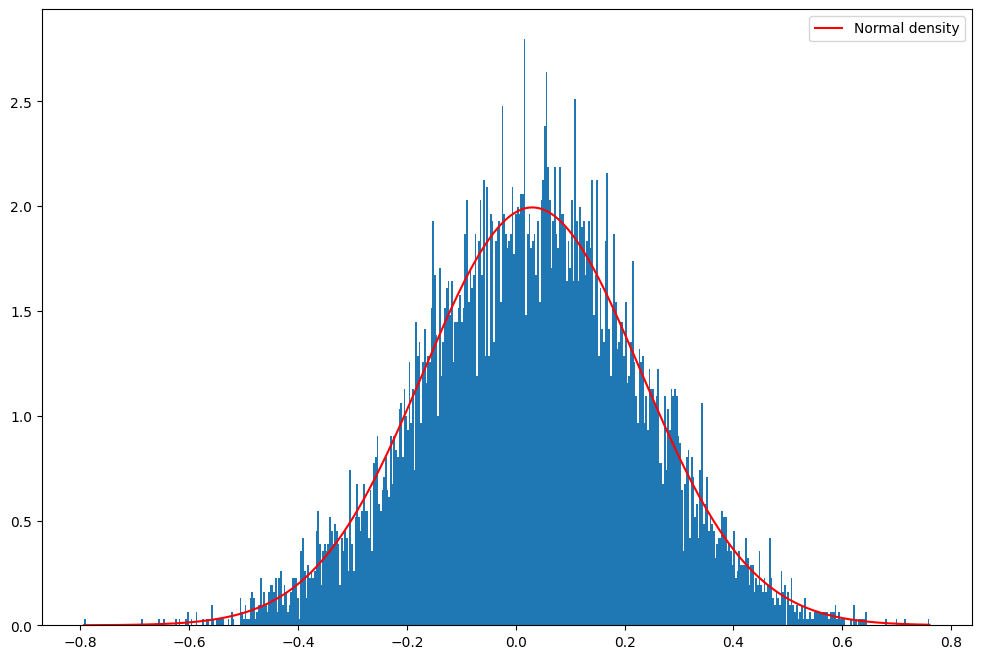

In [10]:
plt.figure(figsize=(12, 8))
plt.hist(retS, density=True, bins=500)
plt.plot(y, ss.norm.pdf(y, retS.mean(), retS.std()), color="r", label="Normal density")
plt.legend()
plt.show()

In [11]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

In [12]:
# Heston given parameters
v0 = 0.04
kappa_v = 2
sigma_v = 0.2
theta_v = 0.04
rho = -0.9


# Generating random numbers from standard normal
rand = random_number_gen(M, I)


# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
HS = Heston_paths(S0, r, V, 0, cho_matrix)

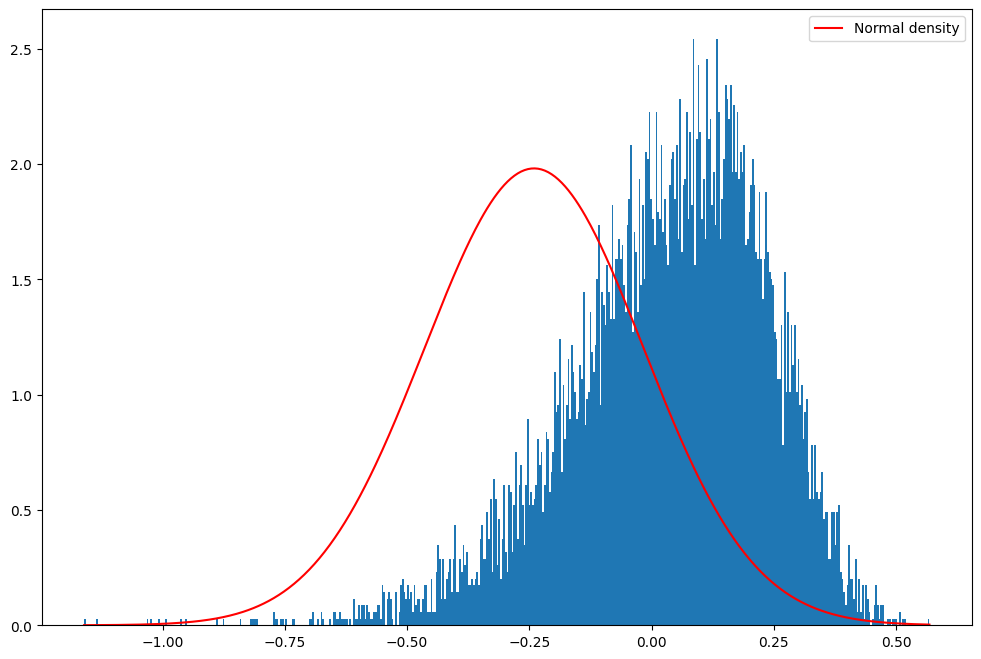

In [13]:
retHS = np.log(HS[-1, :] / S0)
q = np.linspace(retHS.min(), retHS.max(), 500)


plt.figure(figsize=(12, 8))
plt.hist(retHS, density=True, bins=500)
plt.plot(
    q, ss.norm.pdf(y, retHS.mean(), retHS.std()), color="r", label="Normal density"
)
plt.legend()
plt.show()

As we have seen in the previous lessons, this is the distribution of returns produced by Heston.

These clear differences between the different models are also evident just by looking at the kind of stock price paths they produce:

Text(0.5, 0, 'Time Step')

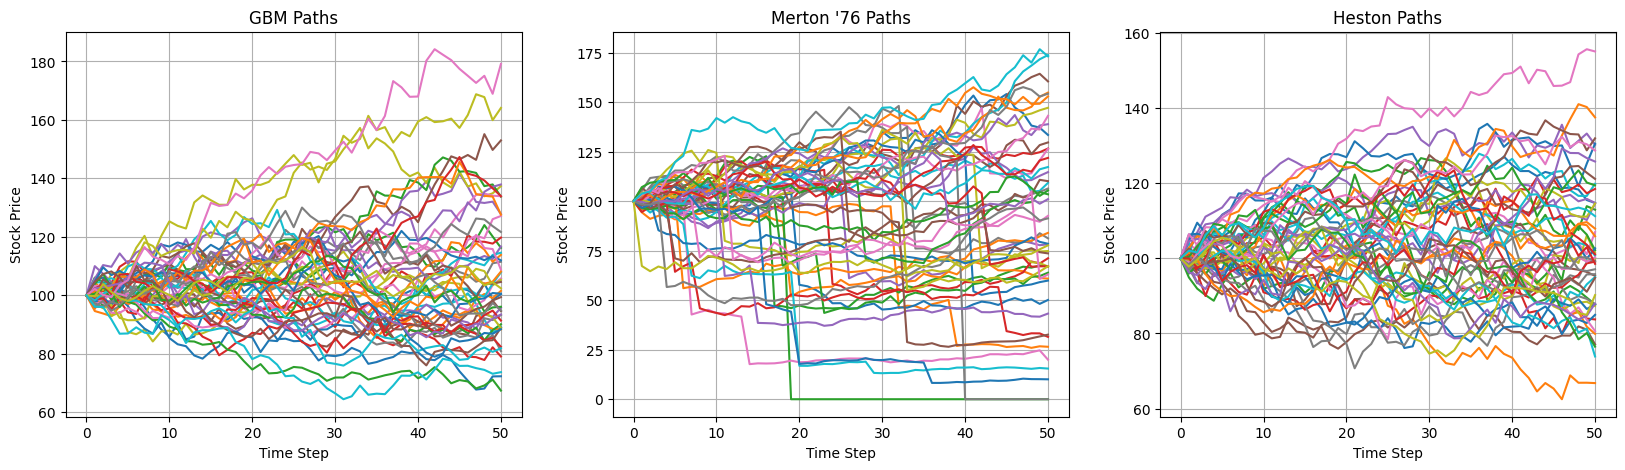

In [14]:
fig = plt.figure(figsize=(20, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.plot(S[:, :50])
ax1.grid()
ax1.set_title("GBM Paths")
ax1.set_ylabel("Stock Price")
ax1.set_xlabel("Time Step")

ax2.plot(SM[:, :50])
ax2.grid()
ax2.set_title("Merton '76 Paths")
ax2.set_ylabel("Stock Price")
ax2.set_xlabel("Time Step")

ax3.plot(HS[:, :50])
ax3.grid()
ax3.set_title("Heston Paths")
ax3.set_ylabel("Stock Price")
ax3.set_xlabel("Time Step")

## **3. Option Pricing under the Different Models**

Next, let's explore the consequences of these differences in option pricing. For simplicity, let's assume a European call option with $K=90$ and $T=1$ year. Let's use Monte Carlo methods for this and assume the parameters from before.

### 3.1. Pricing under Black-Scholes (GBM)

In [15]:
def bs_call_mc(S, K, r, sigma, T, t, Ite):
    data = np.zeros((Ite, 2))
    z = np.random.normal(0, 1, [1, I])
    ST = S * np.exp((T - t) * (r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
    data[:, 1] = ST - K

    average = np.sum(np.amax(data, axis=1)) / float(Ite)

    return np.exp(-r * (T - t)) * average

In [16]:
print("European Call Price under BS (MC): ", bs_call_mc(S0, 90, r, sigma, T, 0, I))

European Call Price under BS (MC):  16.75200689604751


### 3.2 Pricing under Heston

In [17]:
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)

    average = np.mean(payoff)

    return np.exp(-r * (T - t)) * average

In [18]:
print("European Call Price under Heston: ", heston_call_mc(HS, 90, r, T, 0))

European Call Price under Heston:  17.1717494091239


### 3.3 Pricing under Merton

In [19]:
def merton_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)

    average = np.mean(payoff)

    return np.exp(-r * (T - t)) * average

In [20]:
print("European Call Price under Merton: ", merton_call_mc(SM, 90, r, T, 0))

European Call Price under Merton:  27.524765337863204


Are these results for the price of the options consistent with the distributions we observed?

- For instance, if we observe that Merton paths usually lead to higher prices and exhibit more volatility, it should be the case that Call option price under Merton is larger.


## **4. Discussion of Merton Model Parameters**

Finally, let's discuss empirically how the different parameters from Merton influence the type and form of the distribution of stock returns. Specifically, we will focus on the parameters $\lambda$ and $\mu_j$:

- $\lambda$ → Intensity (frequency) of the jump (shock) to stock prices

- $\mu_j$ → Average jump size (can be positive or negative)

As we have already mentioned more than a few times, the actual values that we will use for these parameters will come from a calibration to observed option market prices.

While we will tackle this issue soon, for now, it will be helpful to understand what the sign and magnitude of these parameters mean from an empirical standpoint.

### 4.1. Changing $\lambda$

In the previous example, we used a $\lambda=0.75$, which accounted for the intensity (frequency) of the jumps in interval $t$. In this case, we expect $0.75$ events in a year on average. In other words, the average rate at which jumps occur is 0.75 (75\%).

What will happen to the previous distribution of returns if we increase (or decrease) this number?

Let's check:

In [21]:
lamb = 0.99  # Lambda of the model
mu = -0.6  # Mu
delta = 0.25  # Delta

r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
T = 1.0  # Maturity/time period (in years)
S0 = 100  # Current Stock Price

I = 10000  # Number of simulations (paths)
M = 50  # Number of steps
dt = T / M  # Time-step

SM = np.zeros((M + 1, I))
SM[0] = S0

# rj
rj = lamb * (np.exp(mu + 0.5 * delta**2) - 1)

# Random numbers
z1 = np.random.standard_normal((M + 1, I))
z2 = np.random.standard_normal((M + 1, I))
y = np.random.poisson(lamb * dt, (M + 1, I))

In [22]:
for t in range(1, M + 1):
    SM[t] = SM[t - 1] * (
        np.exp((r - rj - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z1[t])
        + (np.exp(mu + delta * z2[t]) - 1) * y[t]
    )
    SM[t] = np.maximum(
        SM[t], 0.00001
    )  # To ensure that the price never goes below zero!

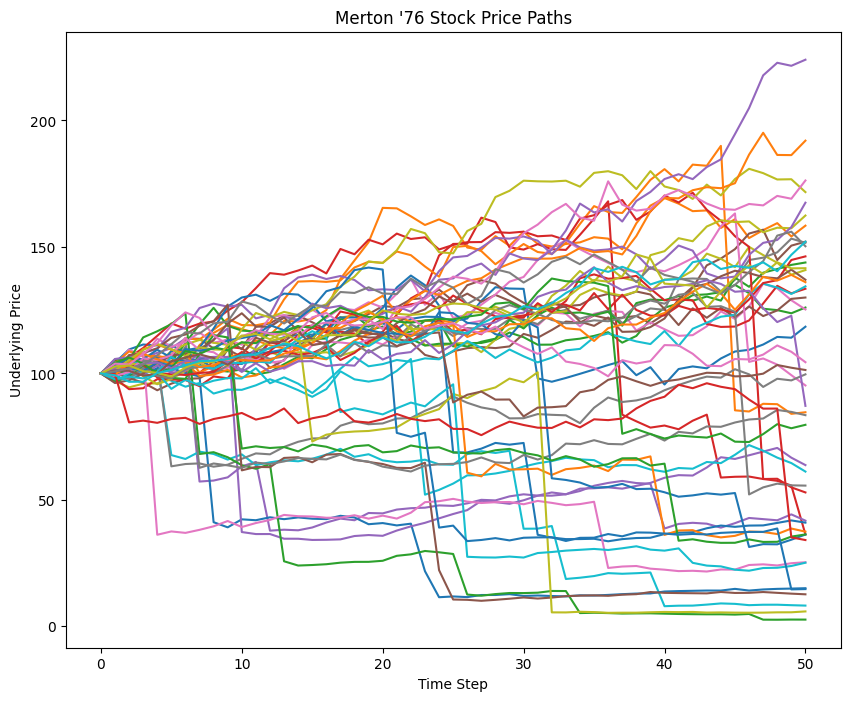

In [23]:
plt.figure(figsize=(10, 8))
plt.plot(SM[:, 100:150])
plt.title("Merton '76 Stock Price Paths")
plt.xlabel("Time Step")
plt.ylabel("Underlying Price")
plt.show()

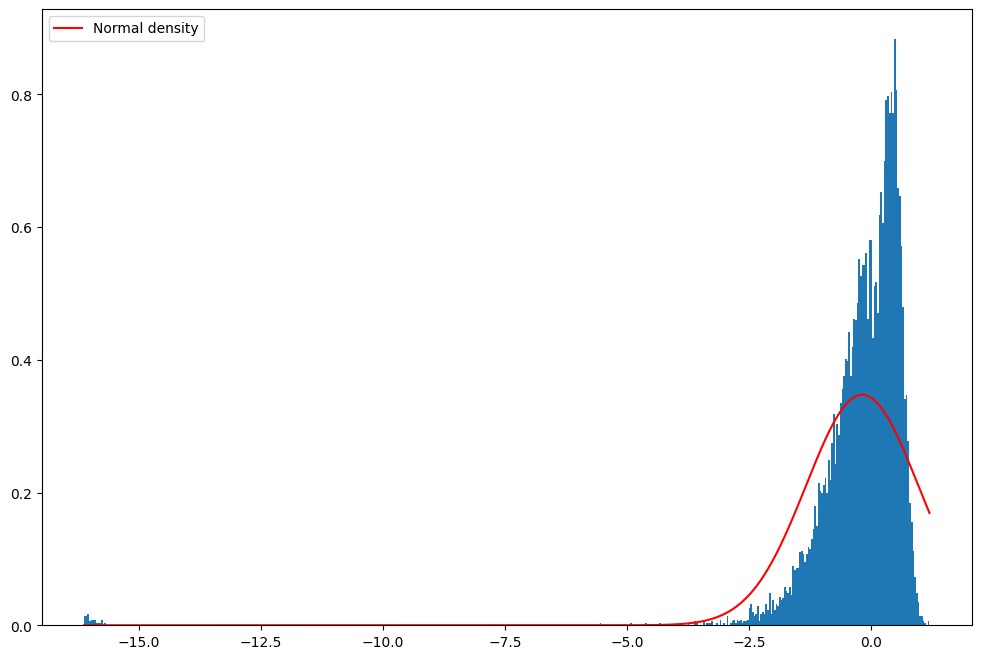

In [24]:
retSM = np.log(SM[-1, :] / S0)
x = np.linspace(retSM.min(), retSM.max(), 500)

plt.figure(figsize=(12, 8))
plt.hist(retSM, density=True, bins=500)
plt.plot(
    x, ss.norm.pdf(x, retSM.mean(), retSM.std()), color="r", label="Normal density"
)
plt.legend()
plt.show()

If you compare this density graph to the one we obtained in the case of $\lambda=0.75$, you will observe that the main difference occurs in the extreme left tail of the distribution. This makes sense, since by increasing $\lambda$ we are effectively influencing the probability that the stock price experiences more negative returns (jumps).

What if we decrease $\lambda$?

### 4.2. Changing $\mu_j$

In the previous case, we observe how the distribution's negative skewness increases as a consequence of a higher $λ$. But why the left tail? Essentially, because we have a $\mu_j<0$. That is, the average jump size is negative. This means that every time the stock price experiences a jump, there is a very high likelihood that this is a negative jump.

What if we set $\mu_j>0$?

In [25]:
lamb = 0.75  # Lambda of the model
mu = 0.6  # Mu
delta = 0.25  # Delta

r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
T = 1.0  # Maturity/time period (in years)
S0 = 100  # Current Stock Price

Ite = 10000  # Number of simulations (paths)
M = 50  # Number of steps
dt = T / M  # Time-step

SM = np.zeros((M + 1, Ite))
SM[0] = S0

# rj
rj = lamb * (np.exp(mu + 0.5 * delta**2) - 1)

# Random numbers
z1 = np.random.standard_normal((M + 1, Ite))
z2 = np.random.standard_normal((M + 1, Ite))
y = np.random.poisson(lamb * dt, (M + 1, Ite))

In [26]:
for t in range(1, M + 1):
    SM[t] = SM[t - 1] * (
        np.exp((r - rj - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z1[t])
        + (np.exp(mu + delta * z2[t]) - 1) * y[t]
    )
    SM[t] = np.maximum(
        SM[t], 0.00001
    )  # To ensure that the price never goes below zero!

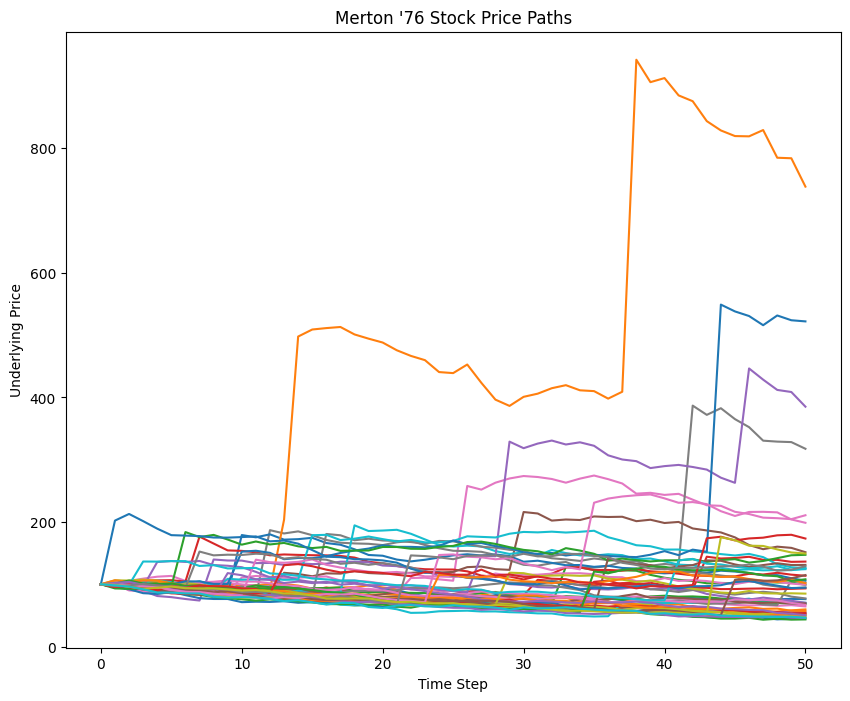

In [27]:
plt.figure(figsize=(10, 8))
plt.plot(SM[:, 50:100])
plt.title("Merton '76 Stock Price Paths")
plt.xlabel("Time Step")
plt.ylabel("Underlying Price")
plt.show()

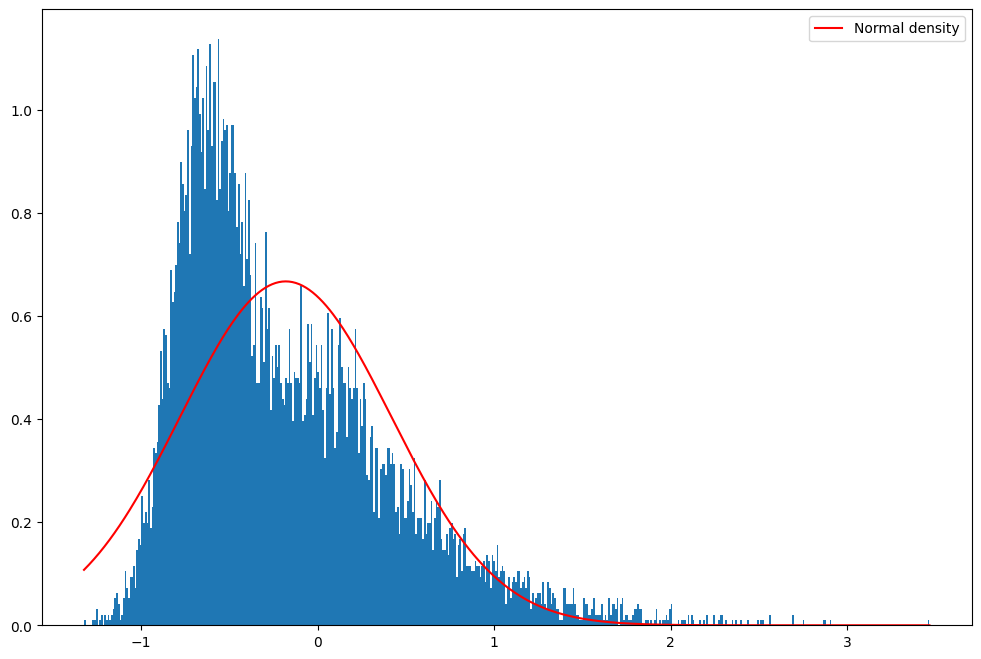

In [28]:
retSM = np.log(SM[-1, :] / S0)
x = np.linspace(retSM.min(), retSM.max(), 500)

plt.figure(figsize=(12, 8))
plt.hist(retSM, density=True, bins=500)
plt.plot(
    x, ss.norm.pdf(x, retSM.mean(), retSM.std()), color="r", label="Normal density"
)
plt.legend()
plt.show()